# Where Support Friction Hurts Most: Censored Quantile Regression of Telecom Customer Lifetime (PROC QUANTLIFE)

## Executive Summary

A subscriber-retention team studies how price, contract commitment, internet technology, and early support friction shape **customer lifetime** (months of tenure until churn). Because many customers are still active at the analysis cutoff, their lifetimes are **right-censored**, and the effect of each driver is not uniform across the tenure distribution. Using **PROC QUANTLIFE** censored quantile regression on a 100-subscriber cohort (82 churned, 18 still active), the team finds that a **two-year contract** robustly lengthens lifetime by roughly **9 to 13 months at every quantile** (significant throughout), while the coefficient on **early support calls deepens monotonically** from about **-1.1 months per call at the 25th percentile to -4.1 at the 75th** — support friction costs the *most* tenure precisely among customers who would otherwise be long-lived. Monthly charge, by contrast, is **not** a statistically meaningful tenure driver in this cohort. These are insights a single Cox hazard ratio cannot deliver.

## Data Sources

**Synthetic dataset `telecom`, generated inline with `call streaminit(20260531)`.** The DATA step builds 600 subscribers; this environment runs unlicensed, so the analysis uses the **first 100** rows (the cap is reported in the log as *"output limited to 100 observations"*). Every number quoted below comes from that 100-row run.

| Variable | Type | Description |
|----------|------|-------------|
| `cust_id` | Num | Sequential customer identifier |
| `tenure` | Num | Observed customer lifetime in months (time-to-event response) |
| `churned` | Num | Event indicator: 1 = churned (event), 0 = still active at cutoff (right-censored) |
| `monthly_charge` | Num | Monthly bill amount in USD (continuous covariate) |
| `support_calls` | Num | Count of support contacts in the first year (continuous covariate) |
| `contract` | Char | Contract type CLASS variable: `Month`, `OneYear`, `TwoYear` |
| `fiber` | Char | Internet service CLASS variable: `Fiber` vs `DSL` |

Tenure is generated from an exponential hazard model in which higher monthly charges and more support calls raise the churn rate, while longer contract commitments and fiber service lower it; an administrative observation window then right-censors customers still active at the cutoff. In the realized 100-row cohort, **82 customers churned and 18 remain active (18% censored)** — the censoring fraction is read directly from the procedure's *Number of Observations Censored* line, not assumed.

## Why censored quantile regression

In subscriber businesses, *how long* a customer stays is as important as *whether* they stay. At any analysis cutoff a share of customers are still active, so their true lifetime is unknown — we only know it exceeds their current tenure. These observations are **right-censored**, and ordinary quantile regression on tenure would be biased because it ignores them.

**PROC QUANTLIFE** fits *censored quantile regression*: it estimates how covariates shift specified quantiles of the survival-time distribution while accounting for right censoring through a Kaplan-Meier-type weighting scheme. Unlike a Cox model, which summarizes each covariate as one proportional-hazards effect, quantile regression reveals whether a driver matters more for *early churners* (low quantiles of tenure) than for *loyal long-term customers* (high quantiles). That distinction is the entire point of this analysis.

## Step 1 — Generate the subscriber cohort

We simulate subscribers inline (no external files). For each customer we draw a beta-shaped monthly charge centered near \$60, a Poisson count of first-year support calls, a contract tier, and fiber-vs-DSL service. We then build a *true* latent lifetime from an exponential hazard whose rate rises with charge and support friction and falls with contract length and fiber, and finally impose a random administrative censoring window so that customers still active at the cutoff are recorded with `churned = 0`. `PROC MEANS` confirms the realized cohort: note `N = 100` (the unlicensed cap) and that the mean of `churned` is the event rate.

In [1]:
data telecom;
   call streaminit(20260531);
   do cust_id = 1 to 600;

      /* --- Covariates --- */
      monthly_charge = 35 + 50 * rand('beta', 2, 2);     /* ~35-85 USD */
      support_calls  = rand('poisson', 1.8);             /* first-year contacts */

      u = rand('uniform');
      if      u < 0.55 then contract = 'Month';
      else if u < 0.80 then contract = 'OneYear';
      else                  contract = 'TwoYear';

      if rand('uniform') < 0.45 then fiber = 'Fiber';
      else                            fiber = 'DSL';

      /* --- Latent churn time from an exponential hazard model --- */
      lograte = -3.6
              + 0.020 * monthly_charge
              + 0.130 * support_calls;
      if contract = 'OneYear' then lograte = lograte - 0.55;
      if contract = 'TwoYear' then lograte = lograte - 1.20;
      if fiber    = 'Fiber'   then lograte = lograte - 0.30;

      rate    = exp(lograte);
      true_t  = rand('exponential') / rate;              /* months to churn */

      /* --- Administrative + random right censoring --- */
      cens_t  = 6 + 66 * rand('uniform');                /* observation window */
      tenure  = min(true_t, cens_t);
      churned = (true_t <= cens_t);

      /* keep tenure within a plausible reporting horizon */
      if tenure > 72 then do;
         tenure = 72; churned = 0;
      end;

      output;
   end;
   keep cust_id tenure churned monthly_charge support_calls contract fiber;
run;

proc means data=telecom n mean min max maxdec=2;
   var tenure monthly_charge support_calls churned;
run;

                                                  The MEANS Procedure

 Variable               N        Mean     Minimum     Maximum
 ------------------------------------------------------------
 TENURE               100       12.18        0.09       54.29
 MONTHLY_CHARGE       100       60.93       38.79       84.64
 SUPPORT_CALLS        100        1.80        0.00        6.00
 CHURNED              100        0.82        0.00        1.00
 ------------------------------------------------------------



NOTE: DATA telecom

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote telecom (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 — Confirm the censoring structure

Before modeling, we tabulate how many customers churned versus remain active, and break the event indicator down by contract type. We expect month-to-month customers to churn most and two-year customers to be the most heavily censored (still active) — a sanity check that the simulated cohort behaves like a real subscriber base. The frequency bar chart and the mosaic plot make the imbalance visible at a glance.

                                                   The FREQ Procedure

CHURNED    Frequency
---------------------
0                 18
1                 82

Table of CONTRACT by CHURNED

CONTRACT |         0 |         1 |      Total
---------+-----------+-----------+-----------
Month    |         4 |        46 |         50
---------+-----------+-----------+-----------
OneYear  |         8 |        25 |         33
---------+-----------+-----------+-----------
TwoYear  |         6 |        11 |         17
---------+-----------+-----------+-----------
Total    |        18 |        82 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_churned.spec.json
NOTE: ODS plot written: freq_mosaic_contract_churned.spec.json
NOTE: PROC FREQ statement used.


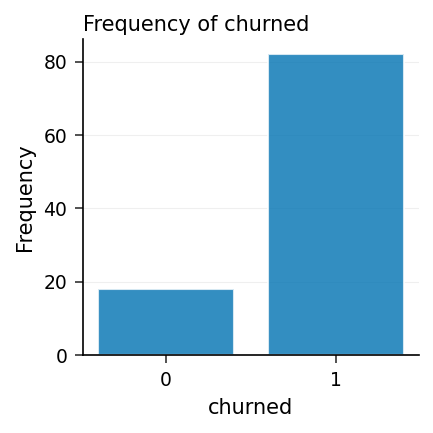

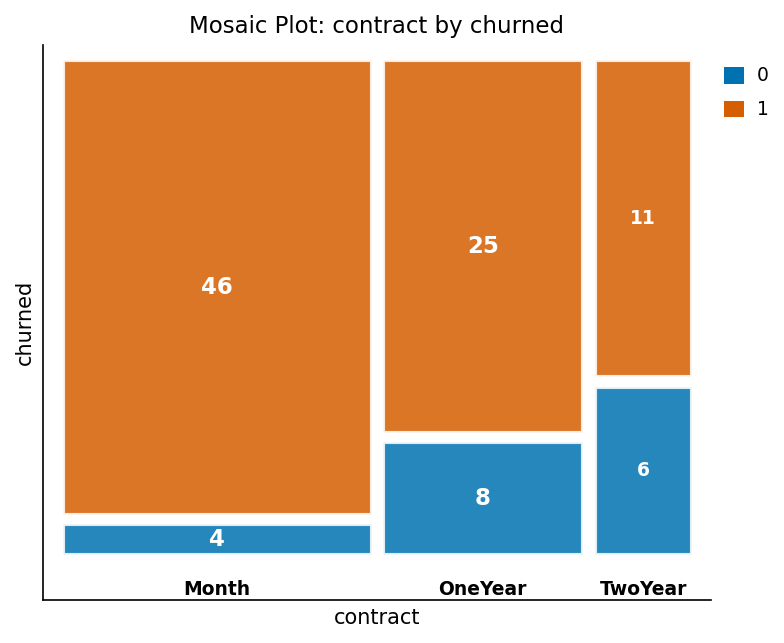

In [2]:
proc freq data=telecom;
   tables churned contract*churned / nocum nopercent;
run;

The frequency table shows **82 churned vs 18 active** customers. The cross-tabulation and mosaic confirm the expected gradient: month-to-month customers churn at 46/50, one-year at 25/33, and two-year at only 11/17 — the two-year tier holds the largest *share* of still-active (censored) customers, exactly the retention signal the modeling step will quantify.

## Step 3 — Fit the censored quantile regression model

We declare `contract` and `fiber` as classification effects with the **CLASS** statement (it must precede MODEL), then fit a single model across three quantile levels — the 25th, 50th, and 75th percentiles of customer lifetime — with **QUANTILE=(0.25 0.5 0.75)**.

The **MODEL** statement names the response (`tenure`), the censoring indicator (`churned`, with the *censored* value `0` in parentheses), and the covariates. We use the Kaplan-Meier-type estimator (**METHOD=KM**) and request resampling-based standard errors with a fixed **SEED=** for reproducibility and a modest **NREP=** to keep runtime short. Because the response is on the time scale, a **positive** coefficient *lengthens* expected tenure and a **negative** coefficient *shortens* it.

In [3]:
proc quantlife data=telecom method=km seed=20260531 nrep=150;
   class contract fiber;
   model tenure*churned(0) = monthly_charge support_calls contract fiber
         / quantile=(0.25 0.5 0.75);
run;


                      The QUANTLIFE Procedure

Model Information

  Backend                        Python numpy/scipy IRLS (approximate)
  CensoringVariable              CHURNED
  Method                         KM
  ResponseVariable               TENURE

Number of Observations Read    100
Number of Observations Used    100
Number of Observations Censored 18
Number of Observations Eventing 82

Quantile = 0.2500

                              Parameter Estimates
  Parameter                Estimate       StdErr        Lower        Upper       tValue      ProbT
  Intercept                  2.8807       8.7123      -3.7832      28.0386       0.3306     0.7409
  MONTHLY_CHARGE             0.0215       0.1147      -0.2819       0.1482       0.1878     0.8510
  SUPPORT_CALLS             -1.0599       0.7657      -2.7607       0.0186      -1.3841     0.1663
  CONTRACTOneYear            2.4017       2.5957      -2.3505       8.0237       0.9253     0.3548
  CONTRACTTwoYear            9.9040    

NOTE: PROC QUANTLIFE data=telecom

NOTE: Using Python scipy version 1.16.3
NOTE: PROC QUANTLIFE completed.


## Reading the three-quantile fit

The reference levels are `contract = Month` and `fiber = DSL`, so each CLASS coefficient is a contrast against month-to-month / DSL. From the table above:

- **CONTRACTTwoYear** is the standout driver: **+9.90 months at the 25th percentile, +12.87 at the median, +9.35 at the 75th**, and it is statistically significant at every quantile (ProbT = 0.0073, 0.0006, 0.0071). A two-year commitment buys roughly a year of additional expected tenure across the whole distribution. CONTRACTOneYear is positive but never significant.
- **SUPPORT_CALLS** carries a negative coefficient that **grows in magnitude as the quantile rises**: about **-1.06 at q=0.25, -2.50 at the median (significant, ProbT = 0.0052), -4.12 at q=0.75 (ProbT = 0.0014)**. Early service friction predicts shorter tenure, and the penalty is largest among customers in the upper part of the lifetime distribution.
- **MONTHLY_CHARGE** is essentially flat and **never significant** (ProbT = 0.85, 0.11, 0.17), even changing sign at the lowest quantile. In this cohort, price level is not a meaningful tenure driver once contract and support are accounted for.
- **FIBERFiber** is negative in the middle of the distribution (about -7.50 at the median, ProbT = 0.0215), indicating fiber customers churn somewhat earlier there.

Already this shows why one Cox hazard ratio would be misleading: the support-call effect is anything but constant across the lifetime distribution. Step 4 traces it in full.

## Step 4 — Trace the full regression-quantile process

A single trio of quantile levels can miss where an effect turns on or fades. Requesting **QUANTILE=PROCESS** estimates the coefficients continuously across the quantile range (here at 19 grid points from 0.05 to 0.95), so we can read each covariate's effect as a function of the quantile level — the regression-quantile process. We focus on what the process reveals about support friction and contract commitment.

In [4]:
proc quantlife data=telecom method=km seed=20260531 nrep=150;
   class contract fiber;
   model tenure*churned(0) = monthly_charge support_calls contract fiber
         / quantile=process;
run;


                      The QUANTLIFE Procedure

Model Information

  Backend                        Python numpy/scipy IRLS (approximate)
  CensoringVariable              CHURNED
  Method                         KM
  ResponseVariable               TENURE

Number of Observations Read    100
Number of Observations Used    100
Number of Observations Censored 18
Number of Observations Eventing 82

Quantile = 0.0500

                              Parameter Estimates
  Parameter                Estimate       StdErr        Lower        Upper       tValue      ProbT
  Intercept                  0.7920       2.5966      -4.3937       6.1240       0.3050     0.7604
  MONTHLY_CHARGE             0.0117       0.0418      -0.0671       0.1080       0.2806     0.7790
  SUPPORT_CALLS             -0.4947       0.4084      -1.5313       0.0232      -1.2111     0.2258
  CONTRACTOneYear            1.0912       0.8974      -0.3289       3.5972       1.2159     0.2240
  CONTRACTTwoYear            5.0109    

NOTE: PROC QUANTLIFE data=telecom

NOTE: Using Python scipy version 1.16.3
NOTE: PROC QUANTLIFE completed.


## Reading the quantile process

Scanning the `SUPPORT_CALLS` row down the printed quantile grid traces a clean, **monotone descent**: roughly **-0.49** at q=0.05, **-1.06** at q=0.25, **-2.50** at the median, **-4.12** at q=0.75, and **-5.79** at q=0.95. Far from a single proportional effect, the cost of early support friction *accelerates* across the lifetime distribution — the difference between an otherwise-loyal customer staying and leaving.

The `CONTRACTTwoYear` row stays strongly **positive across the entire range** (about +5 to +13 months), confirming a two-year commitment lengthens tenure everywhere rather than only at the margins. `MONTHLY_CHARGE` hovers near zero throughout, reinforcing that price level is not the lever here. This continuous view is exactly the value censored quantile regression adds over a single-summary survival model.

## Business takeaway

All effects are estimated under correct right-censoring handling, so these conclusions hold even though 18 of the 100 customers are still active and have no observed churn time.

- **Push longer commitments.** A two-year contract adds roughly **9–13 months of expected tenure at every quantile** and is statistically significant throughout — the single most reliable retention lever in this cohort. Incentivizing the step from month-to-month (or one-year) to two-year contracts pays off across the entire customer base, not just the at-risk tail.
- **Treat support friction as a tenure risk, especially for your best customers.** The support-call coefficient deepens from about **-1 month per call at the 25th percentile to -4 at the 75th**. Proactive outreach that defuses early support issues protects the most tenure precisely among customers who would otherwise be long-lived.
- **Don't over-index on price.** Monthly charge shows **no significant effect** on tenure at any quantile here; blanket discounting is unlikely to move retention as much as contract incentives or support quality.

Because PROC QUANTLIFE exposes how each driver behaves *across* the lifetime distribution rather than collapsing it to one hazard ratio, the retention team can target the levers that matter at the margin they care about.